In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("/content/House Price India.csv")

# data cleaning

# handling null values (Nan) if present

df.drop(['id', 'Date'], axis = 1, inplace = True)

print(f" dataframe head : {df.head()}")
print(f" dataframe shape : {df.shape}")
print(f" dataframe info : {df.info()}")

# handling null values

print(f"null values : {df.isnull().sum()}")

 dataframe head :    number of bedrooms  number of bathrooms  living area  lot area  \
0                   5                 2.50         3650      9050   
1                   4                 2.50         2920      4000   
2                   5                 2.75         2910      9480   
3                   4                 2.50         3310     42998   
4                   3                 2.00         2710      4500   

   number of floors  waterfront present  number of views  \
0               2.0                   0                4   
1               1.5                   0                0   
2               1.5                   0                0   
3               2.0                   0                0   
4               1.5                   0                0   

   condition of the house  grade of the house  \
0                       5                  10   
1                       5                   8   
2                       3                   8   
3         

In [11]:
for col in df:
  df[col] = pd.to_numeric(df[col], errors = "coerce")

df.fillna(df.mode(numeric_only = True), inplace = True)

if (df.isnull().sum() > 0).any():
    print(f" there are still null values")


y = df['Price']
x = df.drop('Price', axis = 1)

scaler_x = StandardScaler() # Create a scaler for features
scaler_y = StandardScaler() # Create a scaler for the target variable

x_scaled = scaler_x.fit_transform(x) # Scale features
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)) # Scale target and reshape to 2D


x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, # Use scaled features
    y_scaled, # Use scaled target
    random_state = 42,
    test_size = 0.2)

print(f"x_train shape : {x_train.shape}")
print(f"x_test shape : {x_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

x_train shape : (11696, 20)
x_test shape : (2924, 20)
y_train shape : (11696, 1)
y_test shape : (2924, 1)


In [15]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    # eval_metric is typically for classification, remove for regression
    tree_method='hist',
    n_jobs=-1
    # scale_pos_weight is for classification imbalance, remove for regression
    )

xgb_model.fit(x_train, y_train)

y_pred = xgb_model.predict(x_test)

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"""
 MSE : {mse},
 R2 : {r2}
 """)


 MSE : 0.10183802868870978,
 R2 : 0.9023882512031236
 


In [16]:
import joblib

joblib.dump(xgb_model, "xg boost model")
print("Model saved as xg boost ")

Model saved as xg boost 


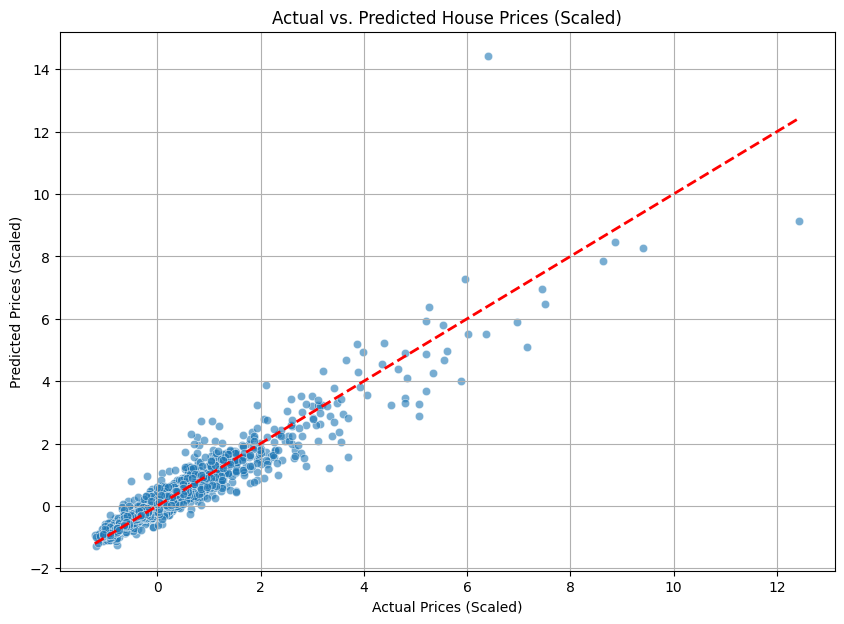

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test.flatten(), y=y_pred.flatten(), alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Predicted House Prices (Scaled)')
plt.xlabel('Actual Prices (Scaled)')
plt.ylabel('Predicted Prices (Scaled)')
plt.grid(True)
plt.show()
